### get data

In [1]:
# Install example dependencies (run once per environment).
%pip install -q -r ../requirements.txt

# Make ``utils/`` importable when this notebook is launched directly
# from this ``notebooks/`` subdirectory.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))


Note: you may need to restart the kernel to use updated packages.


In [2]:
from utils.get_data import (
    get_list_top_n_tickers, 
    download_spot_future_fr_data
)
from utils.process_data import (
    process_ticker
)
from utils.create_features import (
    extract_time_series_features,
    extract_features,
    rsi,
    mfi,
    ema
)
from utils.metrics import (
    smape
)

In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime, timedelta

from catboost import CatBoostRegressor

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.manifold import TSNE
import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

In [4]:
current_time = datetime(
    year = 2025, 
    month = 4, 
    day = 16
)
years = 1
delta = timedelta(days=365 * years)
start_time = current_time - delta

In [5]:
list_top_n_tickers = get_list_top_n_tickers(10)

download_spot_future_fr_data(
    futures_spot_tickers=list_top_n_tickers, 
    start_timestamp=start_time,
    end_timstamp=current_time,
    interval='1h'
)

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:08<01:17,  8.59s/it]

 20%|██        | 2/10 [00:18<01:13,  9.18s/it]

 30%|███       | 3/10 [00:25<00:59,  8.53s/it]

 40%|████      | 4/10 [00:32<00:47,  7.84s/it]

...

 70%|███████   | 7/10 [01:05<00:29,  9.88s/it]

 80%|████████  | 8/10 [01:13<00:18,  9.24s/it]

 90%|█████████ | 9/10 [01:21<00:09,  9.01s/it]

100%|██████████| 10/10 [01:32<00:00,  9.57s/it]

100%|██████████| 10/10 [01:32<00:00,  9.26s/it]

### process data

In [6]:
data = {}
for ticker in tqdm(list_top_n_tickers):
    df_tmp = process_ticker(ticker)
    data[ticker] = df_tmp

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:01,  7.58it/s]

 50%|█████     | 5/10 [00:00<00:00, 19.12it/s]

 80%|████████  | 8/10 [00:00<00:00, 23.02it/s]

100%|██████████| 10/10 [00:00<00:00, 21.42it/s]

In [7]:
features_list = []
tickers = []

for ticker, df in data.items():

    if df.shape[0]:
        train_size = int(df.shape[0] * 0.8)
        df = df.iloc[1:train_size]
        df = df.iloc[7::8]

        if df.shape[0] <= 300:
            print(ticker)
            continue

        fr_series = df['fundingRate']
        feats = extract_time_series_features(fr_series)

        if feats:
            features_list.append(feats)
            tickers.append(ticker)
    else:
        print(ticker)

features_df = pd.DataFrame(features_list, index=tickers)

CHIPUSDT
MEGAUSDT
BANANAS31USDT


In [8]:
features_df.head()

,std,mean_abs_change,acf_lag1,acf_lag2,acf_lag3,trend_slope,trend_r2,rolling_std_24,rolling_mean_24,sign_changes,spike_count_z3,skew,kurtosis,mean_reversion_strength
BTCUSDT,0.831606,0.353806,0.700433,0.603016,0.590142,0.000823,0.062505,0.459847,0.925262,0.115429,0.014857,2.124612,15.644963,-0.700433
ETHUSDT,0.726729,0.299383,0.751267,0.677566,0.662993,0.000719,0.062586,0.370212,0.977511,0.065143,0.020571,1.996639,9.742366,-0.751267
DOGEUSDT,1.027967,0.545763,0.640119,0.575937,0.597607,0.000547,0.018103,0.639464,0.855373,0.189714,0.024000,1.842925,8.885096,-0.640119
BNBUSDT,2.304060,0.650316,0.776799,0.655112,0.625046,0.002830,0.096336,1.103091,-0.059856,0.164571,0.025143,-2.678906,13.834391,-0.776799
SOLUSDT,1.057794,0.543028,0.632255,0.569776,0.572462,0.000070,0.000281,0.668016,0.827856,0.219429,0.021714,0.439668,11.959250,-0.632255


### clusters

Two clustering options:
1. according to the features extracted from the funding rate
2. according to market indicators extracted from the asset price (relative, such as MFI, RSI, etc.)

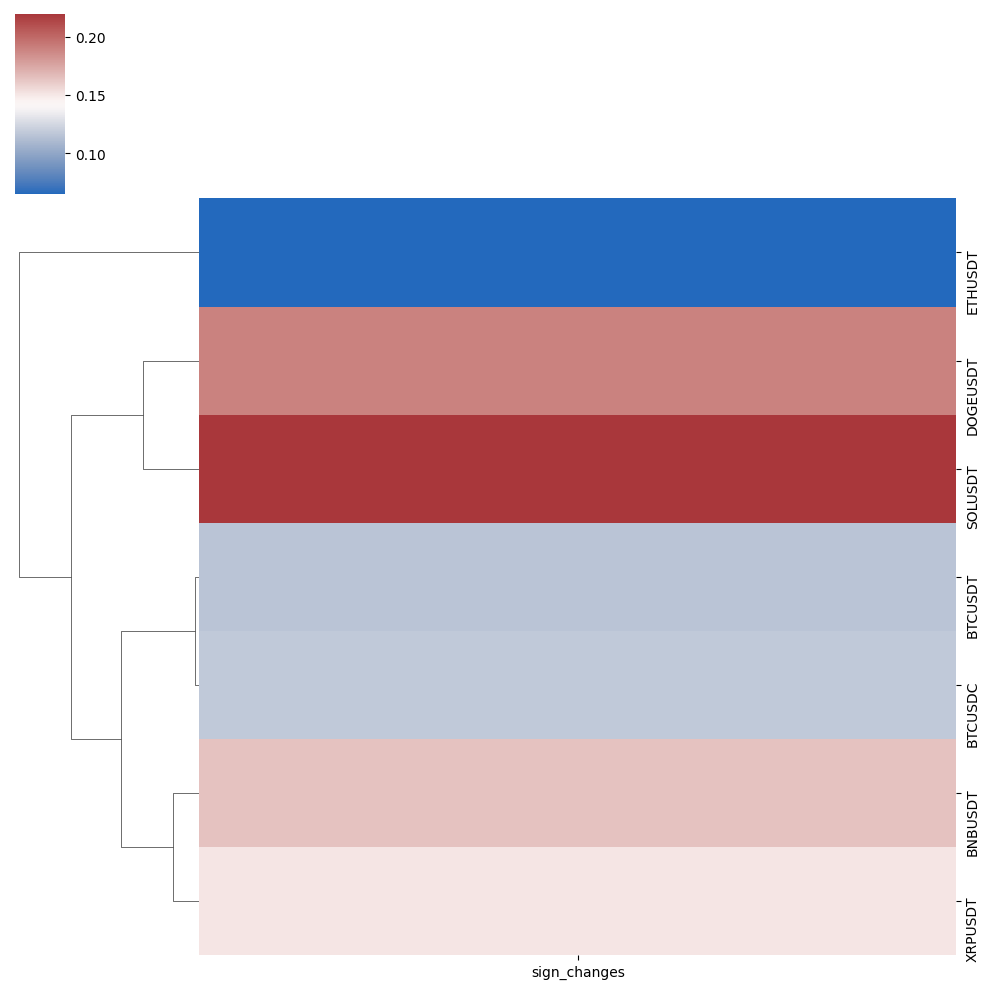

In [9]:
sns.clustermap(features_df['sign_changes'], cmap="vlag", col_cluster=False)
# plt.savefig('images/heatmap_sign_changes.png')

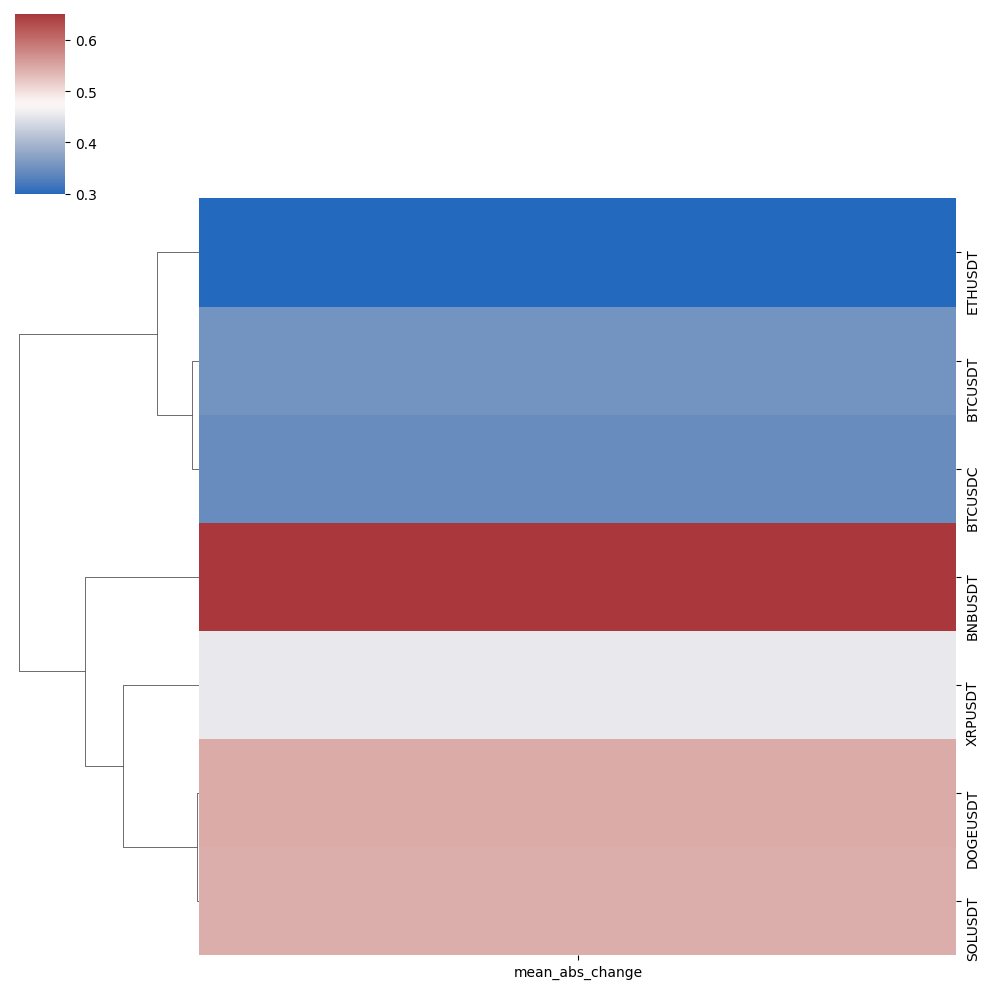

In [10]:
sns.clustermap(features_df['mean_abs_change'], cmap="vlag", col_cluster=False)
# plt.savefig('images/heatmap_mean_fr_change.png')

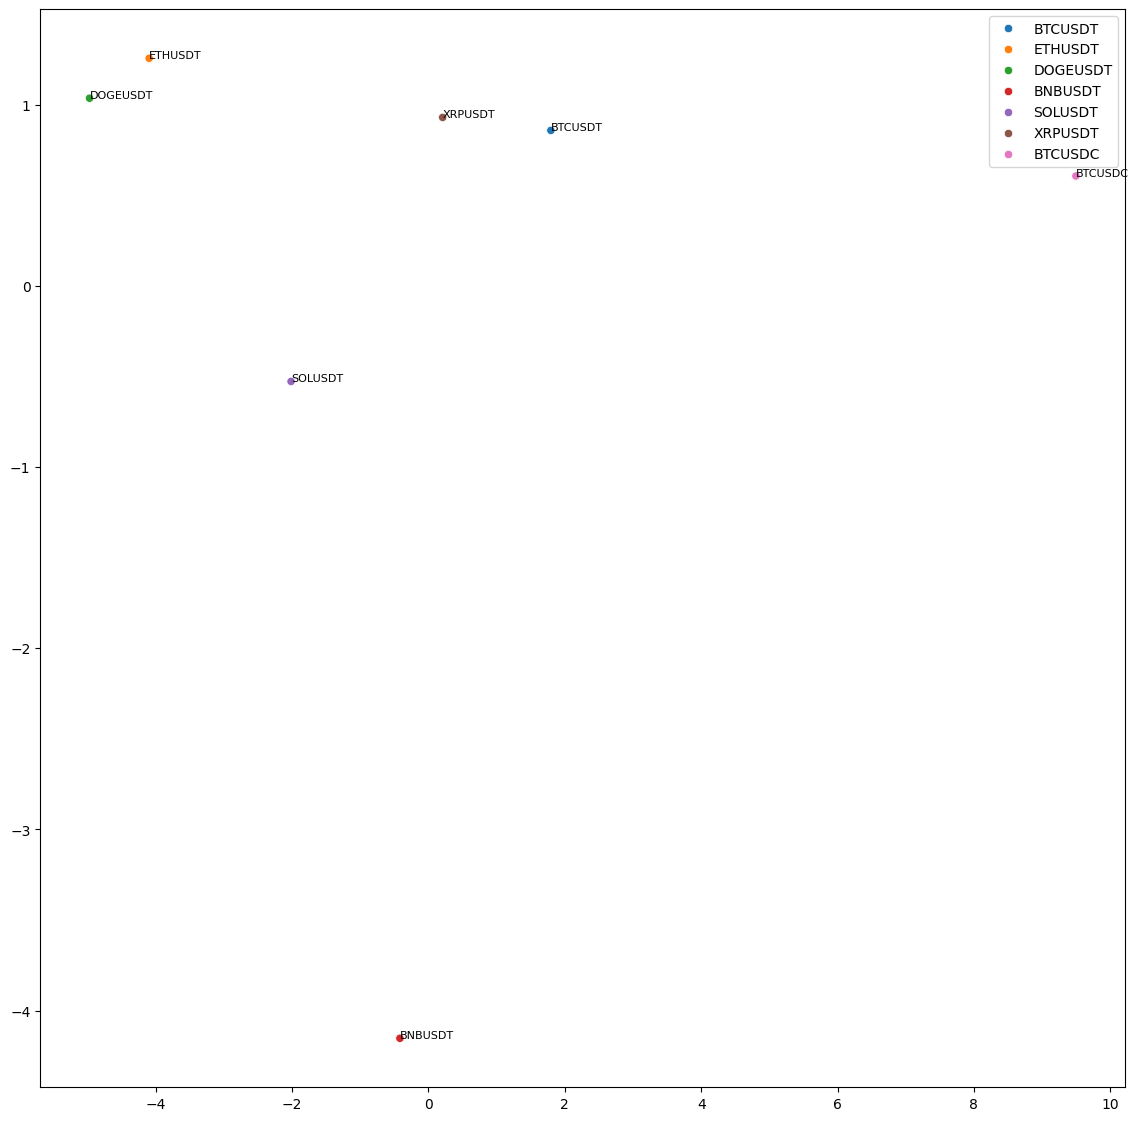

In [11]:
pca = PCA(n_components=2)
components = pca.fit_transform(features_df)

plt.figure(figsize=(14, 14))

sns.scatterplot(x=components[:,0], y=components[:,1], hue=features_df.index.to_list())
for i, ticker in enumerate(features_df.index):
    plt.text(components[i,0], components[i,1], ticker, fontsize=8)

# plt.savefig('images/clusters_PCA.png')

In [12]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df)

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

features_df['cluster'] = cluster_labels

In [13]:
embedding = TSNE(n_components=2, random_state=42, perplexity=2).fit_transform(features_scaled)

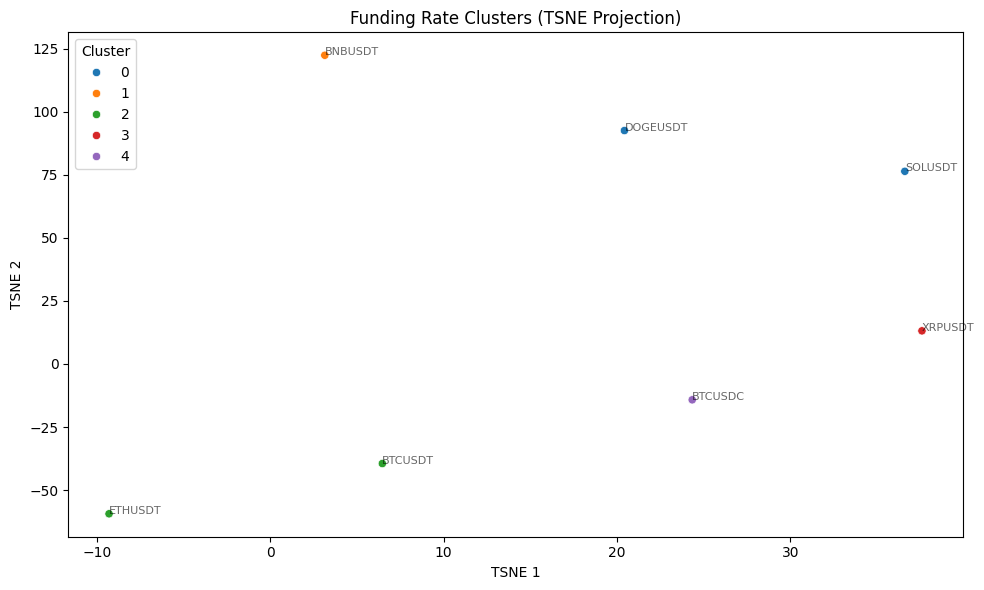

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=cluster_labels, palette='tab10')
for i, ticker in enumerate(tickers):
    plt.text(embedding[i, 0], embedding[i, 1], ticker, fontsize=8, alpha=0.6)
plt.title("Funding Rate Clusters (TSNE Projection)")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.legend(title="Cluster", loc='best')
plt.tight_layout()
# plt.savefig('images/clusters_TSNE_KMeans.png')
plt.show()

In [15]:
def plot_clusters(embedding, labels, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette='tab10', legend='full')
    for i, ticker in enumerate(tickers):
        plt.text(embedding[i, 0], embedding[i, 1], ticker, fontsize=8, alpha=0.5)
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Cluster", loc="best")
    plt.tight_layout()
    plt.show()

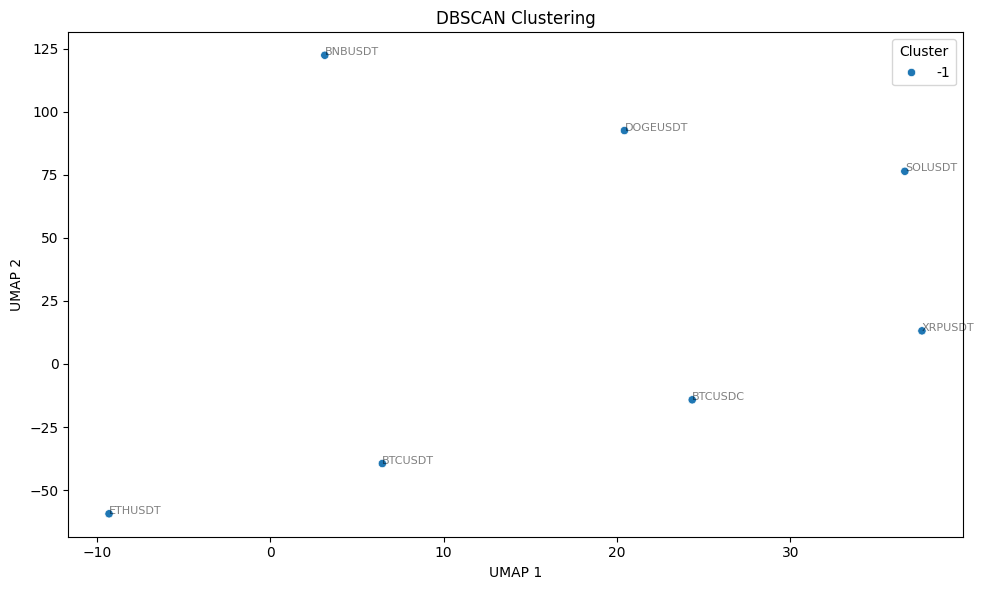

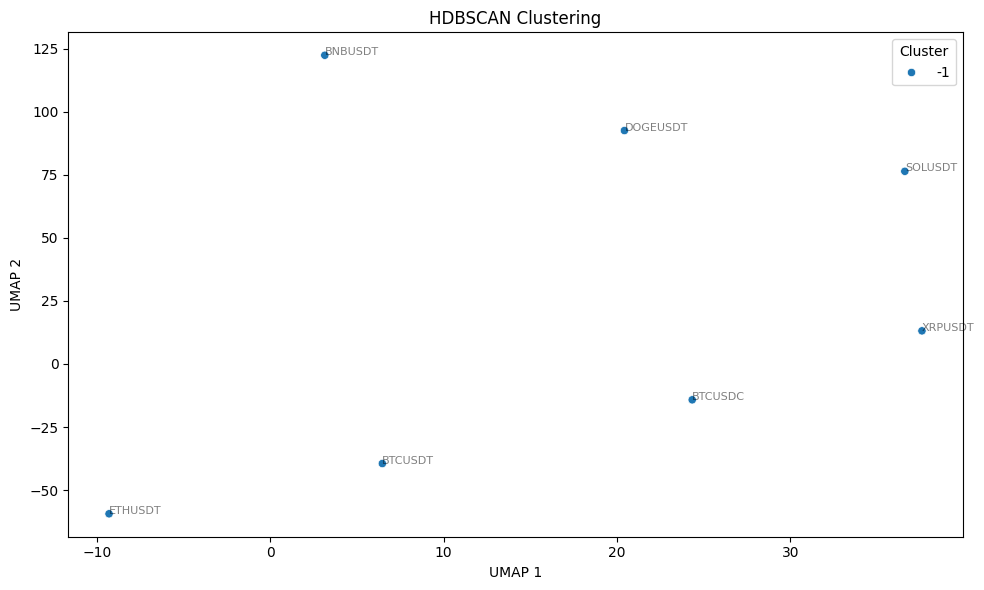

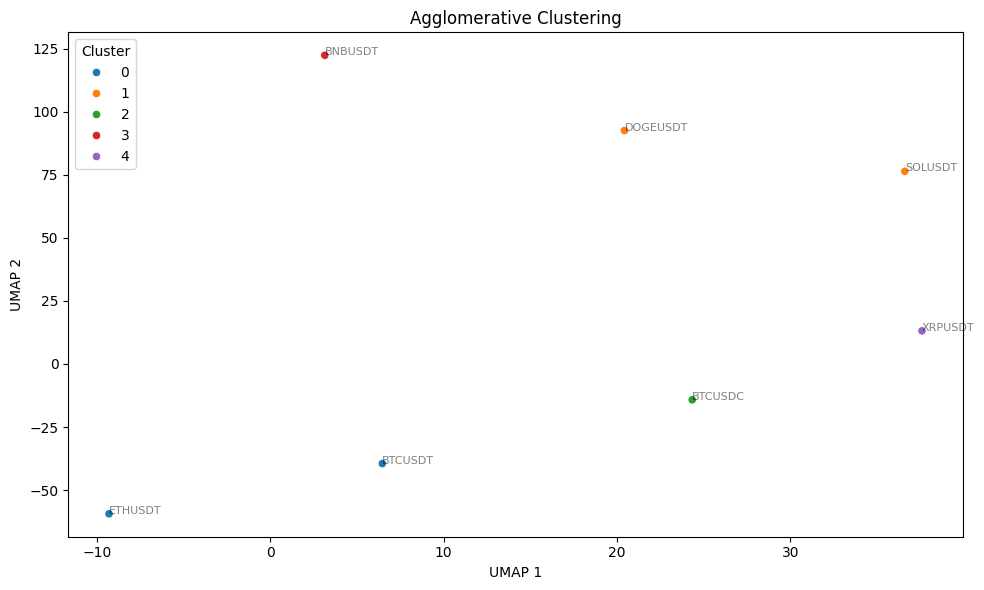

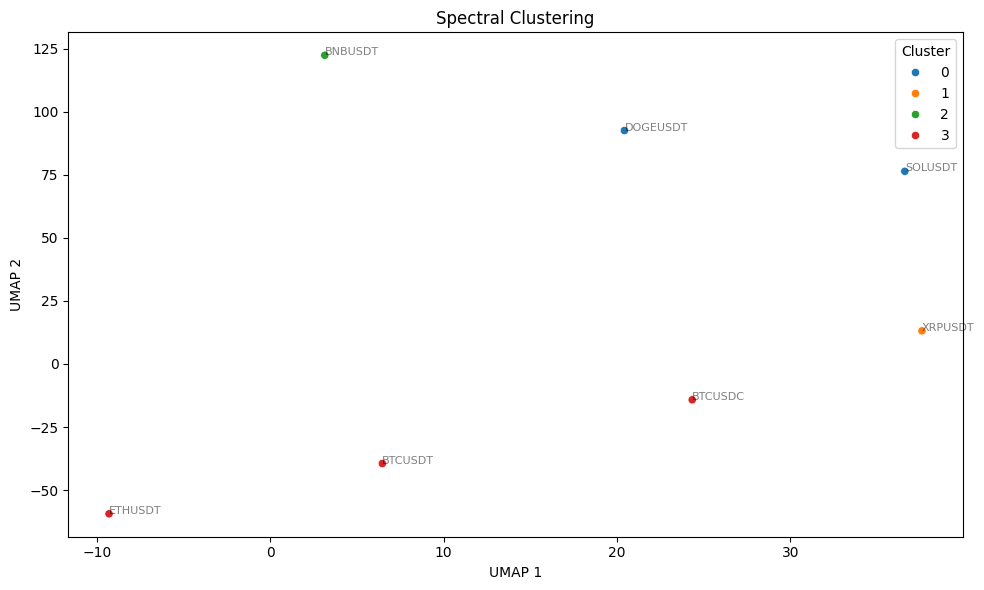

In [16]:
# --- DBSCAN ---
dbscan = DBSCAN(eps=1.2, min_samples=3)
db_labels = dbscan.fit_predict(features_scaled)
plot_clusters(embedding, db_labels, "DBSCAN Clustering")

# --- HDBSCAN ---
hdb = hdbscan.HDBSCAN(min_cluster_size=3)
hdb_labels = hdb.fit_predict(features_scaled)
plot_clusters(embedding, hdb_labels, "HDBSCAN Clustering")

# --- Agglomerative Clustering ---
agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(features_scaled)
plot_clusters(embedding, agg_labels, "Agglomerative Clustering")

# --- Spectral Clustering ---
spectral = SpectralClustering(n_clusters=5, assign_labels="discretize", random_state=42)
spectral_labels = spectral.fit_predict(features_scaled)
plot_clusters(embedding, spectral_labels, "Spectral Clustering")

### research, modeling

In [17]:
df = data['ETHUSDT'].copy()

In [18]:
df['fundingRate'] = df['fundingRate'].shift(-1)
df = df.iloc[:-1]

df['hour_index'] = df['open_time'].str[11:13].astype(int) % 8 + 1

df['basis'] = df['close_futr'] - df['close_spot']
df['basis_relative'] = df['basis'] / df['close_futr']
# Predict 2-step-ahead basis (forecasting horizon, NOT lagged target).
df['target'] = df['basis'].shift(-2)
df = df.iloc[:-2]

df.reset_index(drop=True, inplace=True)

In [19]:
features_df = pd.DataFrame([extract_features(df, i) for i in range(len(df))])

In [20]:
df['volume_ratio'] = df['volume_futr'] / df['volume_spot']
df = pd.concat([df, features_df], axis=1)

In [21]:
df['sma_fr_7'] = df.fundingRate.rolling(8 * 7).mean().shift(1)
df['sma_fr_3'] = df.fundingRate.rolling(8 * 3).mean().shift(1)

df['sma_basis_14'] = df['basis'].rolling(14).mean().shift(1)
df['sma_basis_7'] = df['basis'].rolling(7).mean().shift(1)
df['sma_basis_3'] = df['basis'].rolling(3).mean().shift(1)

windows = [7, 14, 28]
for window in windows:
    df[f'EMA_{window}'] = ema(df, window)
    df[f'RSI_{window}'] = rsi(df, window)
    df[f'MFI_{window}'] = mfi(df, window)

In [22]:
# del data leak
df = df[df['hour_index'] != 8]

In [23]:
cols = [
    'log_return', 'volatility', 'avg_volume_futr', 'avg_volume_spot',
    'basis_mean', 'basis_std', 'hour_index', 'volume_ratio',
    'sma_fr_3', 'sma_fr_7',
    'sma_basis_3', 'sma_basis_7', 'sma_basis_14',
    'RSI_7', 'MFI_7', 'EMA_7', 
    'RSI_14', 'MFI_14', 'EMA_14',
    'RSI_28', 'MFI_28', 'EMA_28',
]
train_size = int(df.shape[0] * 0.8)
x = df.iloc[:train_size][cols]
y = df.iloc[:train_size]['target']

test = df.iloc[train_size:].copy()
x_test = df.iloc[train_size:][cols]
y_test = df.iloc[train_size:]['target']

In [24]:
kwargs = {'iterations': 200, 'depth': 4, 'verbose': False}
model = CatBoostRegressor(**kwargs)
model.fit(x, y)

CatBoostRegressor(depth=4, iterations=200, loss_function='RMSE', verbose=False)

In [25]:
feats = pd.DataFrame()
feats['feature'] = model.feature_names_
feats['importance'] = model.feature_importances_
feats.sort_values(by='importance', ascending=False).head(7)

,feature,importance
12,sma_basis_14,30.362368
4,basis_mean,20.533411
11,sma_basis_7,18.977823
10,sma_basis_3,7.781254
5,basis_std,5.758969
18,EMA_14,4.611609
19,RSI_28,3.265892


In [26]:
# CatBoost results
preds_train = model.predict(x)
smape(y, preds_train)

0.2105778907810102

In [27]:
preds = model.predict(x_test)
test['preds'] = preds

smape(test['target'], test['preds'])


0.17232033303364283

In [28]:
train = df.iloc[:train_size].copy()
train['preds'] = model.predict(x)

train['bin_preds'] = pd.qcut(train['preds'], q=20, duplicates='drop')
train.groupby('bin_preds')['fundingRate'].agg(['count', 'mean'])

,count,mean
bin_preds,,
"(-22.791, -1.506]",307,0.000066
"(-1.506, -1.438]",307,0.000060
"(-1.438, -1.399]",306,0.000062
"(-1.399, -1.36]",307,0.000057
"(-1.36, -1.323]",306,0.000051
"(-1.323, -1.291]",307,0.000046
"(-1.291, -1.254]",306,0.000052
"(-1.254, -1.206]",307,0.000051
"(-1.206, -1.165]",306,0.000061


In [29]:
test['bin_preds'] = pd.qcut(test['preds'], q=10, duplicates='drop')
test.groupby('bin_preds')['fundingRate'].agg(['count', 'mean'])

,count,mean
bin_preds,,
"(-2.472, -1.329]",154,0.000003
"(-1.329, -1.241]",153,0.000034
"(-1.241, -1.144]",153,0.000033
"(-1.144, -1.071]",153,0.000028
"(-1.071, -1.01]",154,0.000022
"(-1.01, -0.945]",153,0.000021
"(-0.945, -0.902]",153,0.000017
"(-0.902, -0.858]",153,0.000018
"(-0.858, -0.781]",153,0.000020


In [30]:
train['bin_preds'] = pd.qcut(train['preds'], q=50, duplicates='drop')
mapping = train.groupby('bin_preds')['fundingRate'].agg(['mean'])
mapping = mapping.to_dict()

def process_prediction(x, mapping):
    prediction = x
    for key, value in mapping['mean'].items():
        left = key.left
        right = key.right
        if prediction > left and prediction < right:
            return value
    return 0.0001

train['preds_fr'] = train['preds'].map(lambda x: process_prediction(x, mapping))
test['preds_fr'] = test['preds'].map(lambda x: process_prediction(x, mapping))

In [31]:
# hour results on train data for price diff and fr
for i in range(1, 8):
    smape_basis = smape(train[train['hour_index'] == i]['target'], train[train['hour_index'] == i]['preds'])
    smape_fr = smape(train[train['hour_index'] == i]['fundingRate'], train[train['hour_index'] == i]['preds_fr'])
    print(i, smape_basis, smape_fr)

1 0.20024807347333712 0.443098651403428
2 0.21900667272719632 0.442744770656433
3 0.2094134019635788 0.44276075882955546
4 0.2085920580656414 0.4441570159737552
5 0.20692948484593893 0.45262335390317415
6 0.21298634356462878 0.4523476444671485
7 0.21687639089537367 0.45796893211673


In [32]:
# hour results on test data for price diff and fr
for i in range(1, 8):
    smape_basis = smape(test[test['hour_index'] == i]['target'], test[test['hour_index'] == i]['preds'])
    smape_fr = smape(test[test['hour_index'] == i]['fundingRate'], test[test['hour_index'] == i]['preds_fr'])
    print(i, smape_basis, smape_fr)

1 0.15691520170839768 1.0931483781751865
2 0.17060187984968403 1.0946364196878016
3 0.17617504332050032 1.0999015704042994
4 0.19193806875139285 1.096761847889854
5 0.18075370641647642 1.0923052178606982
6 0.16420261876189385 1.0844128848947125
7 0.16565581242715463 1.088582153686148


In [33]:
# simple const baseline
smape(test.fundingRate, [0.0001] * len(test))

1.1966080713211544

In [34]:
# rolling mean baseline
smape(test.fundingRate, test.fundingRate.rolling(8 * 3).mean().shift(7))

1.1697662627659233

In [35]:
# CatBoost funding rate results
smape(test.fundingRate, test.preds_fr)

1.0928212103712431

In [36]:
# Correlation between funidng rate on price diff on train data
np.corrcoef(train.fundingRate, train.basis)

array([[1.        , 0.65672142],
       [0.65672142, 1.        ]])

In [37]:
# Correlation between funidng rate on price diff on test data
np.corrcoef(test.fundingRate, test.basis)

array([[1.        , 0.12117086],
       [0.12117086, 1.        ]])